# ML Model

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings("ignore")
 
from sklearn.pipeline          import Pipeline
from sklearn.compose           import ColumnTransformer
from sklearn.preprocessing     import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.linear_model      import LogisticRegression
from sklearn.ensemble          import RandomForestClassifier
from sklearn.model_selection   import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics           import (accuracy_score, f1_score, roc_auc_score, auc , 
                                       confusion_matrix, classification_report,
                                       roc_curve, ConfusionMatrixDisplay)
from imblearn.over_sampling    import SMOTE
import xgboost as xgb
from imblearn.pipeline         import Pipeline as ImbPipeline

In [2]:
df = pd.read_csv('ml_train_data.csv')
display(df.head(5))

,jobs_cut,pct_workforce_cut,company_revenue_2025_bn,pre_layoff_headcount,simultaneous_ai_investment_bn,layoffs_2024,layoffs_2025,region,layoff_size_category,stock_reaction,revenue_per_emp,ai_investment_ratio,layoff_acceleration,cut_scale_normalized,ai_cited_flag,sector_group
0,16000,2.7,716.9,1550000,100.0,4000,14000,North America,Mega (5K+),Positive,0.000463,0.139489,10000,0.010323,0,Cloud/Platform
1,4000,40.0,22.4,10000,2.0,0,1000,North America,Large (2K-5K),Positive,0.002240,0.089286,1000,0.399960,1,Fintech/SaaS
2,1500,10.0,164.5,79000,115.0,0,500,North America,Medium (500-2K),Positive,0.002082,0.699088,500,0.018987,1,Consumer Tech
3,1600,10.0,5.1,16000,0.5,0,500,Asia-Pacific,Medium (500-2K),Positive,0.000319,0.098039,500,0.099994,1,Fintech/SaaS
4,30000,15.0,52.9,200000,40.0,6000,10000,North America,Mega (5K+),Positive,0.000264,0.756144,4000,0.149999,1,Fintech/SaaS


In [3]:
print(df['stock_reaction'].value_counts())
print(df.shape)

stock_reaction
Positive    17
Negative     8
Neutral      3
Name: count, dtype: int64
(28, 16)


In [4]:
# remove Neutral 
df = df[df["stock_reaction"].isin(["Positive", "Negative"])].copy()
df.shape

(25, 16)

In [5]:
x = df.drop(columns=['stock_reaction'])
y = (df["stock_reaction"] == "Positive").astype(int) # positiv = 1 , negetive = 0
categorical_cols = ["region", "layoff_size_category", "sector_group"]
numerical_cols   = [c for c in x.columns if c not in categorical_cols]
print(f"\n  Numerical features   : {len(numerical_cols)} -> {numerical_cols}")
print(f"  Categorical features : {len(categorical_cols)}  → {categorical_cols}")



  Numerical features   : 12 -> ['jobs_cut', 'pct_workforce_cut', 'company_revenue_2025_bn', 'pre_layoff_headcount', 'simultaneous_ai_investment_bn', 'layoffs_2024', 'layoffs_2025', 'revenue_per_emp', 'ai_investment_ratio', 'layoff_acceleration', 'cut_scale_normalized', 'ai_cited_flag']
  Categorical features : 3  → ['region', 'layoff_size_category', 'sector_group']


In [6]:
x_train , x_test , y_train , y_test = train_test_split(x , y , random_state=42 , test_size=0.3 , stratify=y)
print(f"train shape : {x_train.shape} : {y_train.shape}")
print(f"test shape : {x_test.shape} : {y_test.shape}")

train shape : (17, 15) : (17,)
test shape : (8, 15) : (8,)


In [7]:
preprocessor = ColumnTransformer(transformers=[
    ("num", StandardScaler(), numerical_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_cols),
])
preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

In [10]:
#  BUILD PIPELINES  (Preprocessor → SMOTE → Model)
#     Using imblearn Pipeline so SMOTE only runs on training folds

pipelines = {
 
    "Logistic Regression": ImbPipeline(steps=[
        ("preprocessor", preprocessor),
        ("smote",  SMOTE(random_state=42, k_neighbors=2)),
        ("model",  LogisticRegression(C=0.1, max_iter=1000,
                                      class_weight="balanced", random_state=42)),
    ]),
 
    "Random Forest": ImbPipeline(steps=[
        ("preprocessor", preprocessor),
        ("smote",  SMOTE(random_state=42, k_neighbors=2)),
        ("model",  RandomForestClassifier(n_estimators=200, max_depth=4,
                                          class_weight="balanced", random_state=42)),
    ]),
 
    "XGBoost": ImbPipeline(steps=[
        ("preprocessor", preprocessor),
        ("smote",  SMOTE(random_state=42, k_neighbors=2)),
        ("model",  xgb.XGBClassifier(n_estimators=200, max_depth=3,
                                     learning_rate=0.05, subsample=0.8,
                                     colsample_bytree=0.8, eval_metric="logloss",
                                     random_state=42, verbosity=0)),
    ]),
}

for name , pipe in pipelines.items():
    print(f"train : {name}")
    pipe.fit(x_train , y_train)
    print(f"model : {name} trained sucessfully")

train : Logistic Regression
model : Logistic Regression trained sucessfully
train : Random Forest
model : Random Forest trained sucessfully
train : XGBoost
model : XGBoost trained sucessfully


In [11]:
results = []
for name , pipe in pipelines.items():
    y_pred = pipe.predict(x_test)
    accuracy =  accuracy_score(y_test , y_pred)
    y_pred_proba = pipe.predict_proba(x_test)[:,1]
    roc_auc = roc_auc_score(y_test , y_pred_proba)
    report = classification_report(y_test , y_pred , output_dict=True)

    results.append({
        'Model'     : name,
        'Precision' : round(report['1']['precision'], 4),
        'Recall'    : round(report['1']['recall'],    4),
        'F1-Score'  : round(report['1']['f1-score'],  4), # i need to understand this 
        'AUC-ROC'   : round(roc_auc, 4)
    })

    print(f"model : {name}")
    # print(f"prediction : {y_pred}")
    print(f"accuracy : {accuracy}")
    print(f"ROC_AUC : {roc_auc}")
    print(f"{'='*45}")
    print(f"classification report : \n {classification_report(y_test , y_pred)}")
    print(f"{'='*45}")
    print("confusion matrix:")
    print(confusion_matrix(y_test , y_pred))
    print(f"{'='*45} \n ")

model : Logistic Regression
accuracy : 0.625
ROC_AUC : 0.9333333333333333
classification report : 
               precision    recall  f1-score   support

           0       0.50      1.00      0.67         3
           1       1.00      0.40      0.57         5

    accuracy                           0.62         8
   macro avg       0.75      0.70      0.62         8
weighted avg       0.81      0.62      0.61         8

confusion matrix:
[[3 0]
 [3 2]]
 
model : Random Forest
accuracy : 0.75
ROC_AUC : 1.0
classification report : 
               precision    recall  f1-score   support

           0       0.60      1.00      0.75         3
           1       1.00      0.60      0.75         5

    accuracy                           0.75         8
   macro avg       0.80      0.80      0.75         8
weighted avg       0.85      0.75      0.75         8

confusion matrix:
[[3 0]
 [2 3]]
 
model : XGBoost
accuracy : 0.75
ROC_AUC : 1.0
classification report : 
               precision   

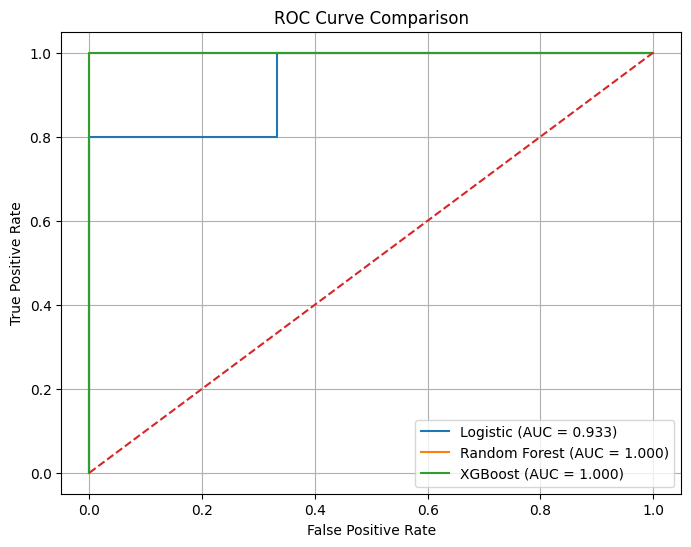

In [15]:
# get probability
log_prob = pipelines['Logistic Regression'].predict_proba(x_test)[:,1]

rf_prob = pipelines['Random Forest'].predict_proba(x_test)[:,1]

xgb_prob = pipelines['XGBoost'].predict_proba(x_test)[:,1]

# ROC curve
fpr_log, tpr_log, _ = roc_curve(y_test, log_prob)
fpr_rf, tpr_rf, _   = roc_curve(y_test, rf_prob)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, xgb_prob)

# AUC score
auc_log = auc(fpr_log, tpr_log)
auc_rf  = auc(fpr_rf, tpr_rf)
auc_xgb = auc(fpr_xgb, tpr_xgb)

plt.figure(figsize=(8,6))

plt.plot(fpr_log, tpr_log, label=f"Logistic (AUC = {auc_log:.3f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {auc_rf:.3f})")
plt.plot(fpr_xgb, tpr_xgb, label=f"XGBoost (AUC = {auc_xgb:.3f})")

# Random baseline
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.grid()
plt.show()


Total features after encoding: 24


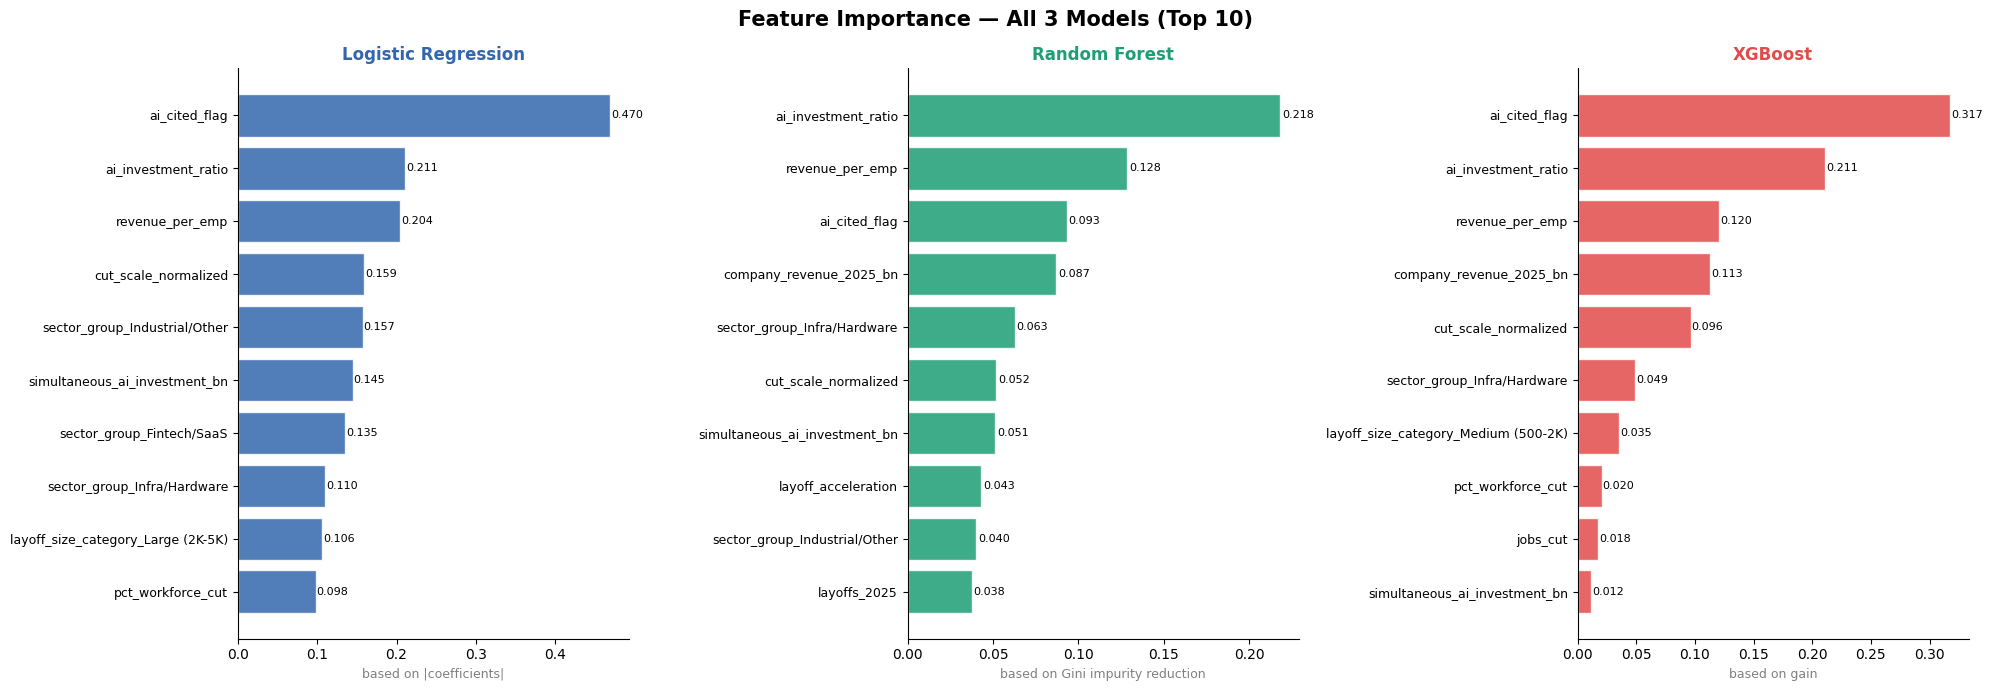

In [18]:
# Step 1: Get feature names AFTER preprocessing (OHE expands categorical cols)
ohe_feature_names = (pipelines["Logistic Regression"]
                     .named_steps["preprocessor"]
                     .named_transformers_["cat"]
                     .get_feature_names_out(categorical_cols)
                     .tolist())

all_feature_names = numerical_cols + ohe_feature_names
print(f"Total features after encoding: {len(all_feature_names)}")

# Step 2: Extract importance scores for each model
def get_importance(pipeline, model_name, feature_names):
    model = pipeline.named_steps["model"]
    
    if model_name == "Logistic Regression":
        # LR uses coefficients — take absolute value (magnitude = importance)
        scores = np.abs(model.coef_[0])
    
    elif model_name == "Random Forest":
        # RF has built-in feature_importances_ (Gini impurity based)
        scores = model.feature_importances_
    
    elif model_name == "XGBoost":
        # XGBoost has built-in feature_importances_ (gain based)
        scores = model.feature_importances_

    return pd.DataFrame({
        "feature"   : feature_names,
        "importance": scores
    }).sort_values("importance", ascending=False).reset_index(drop=True)

importance_dict = {}
for name, pipe in pipelines.items():
    importance_dict[name] = get_importance(pipe, name, all_feature_names)

# Step 3: Plot — Top 10 features per model
model_colors = {
    "Logistic Regression": "#3266ad",
    "Random Forest"      : "#1d9e75",
    "XGBoost"            : "#e24b4a",
}

fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.suptitle("Feature Importance — All 3 Models (Top 10)", 
             fontsize=15, fontweight="bold")

for ax, (name, imp_df) in zip(axes, importance_dict.items()):
    top10 = imp_df.head(10).iloc[::-1]   # reverse so highest bar is on top
    
    bars = ax.barh(top10["feature"], top10["importance"],
                   color=model_colors[name], alpha=0.85, edgecolor="white")
    
    # value labels on bars
    for bar in bars:
        ax.text(bar.get_width() + 0.001, 
                bar.get_y() + bar.get_height() / 2,
                f"{bar.get_width():.3f}", 
                va="center", fontsize=8)

    ax.set_title(name, fontsize=12, fontweight="bold", color=model_colors[name])
    ax.set_xlabel("Importance Score" if name == "Logistic Regression" 
                  else "Feature Importance", fontsize=10)
    ax.tick_params(axis="y", labelsize=9)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # subtitle explaining what importance means for this model
    subtitles = {
        "Logistic Regression": "based on |coefficients|",
        "Random Forest"      : "based on Gini impurity reduction",
        "XGBoost"            : "based on gain",
    }
    ax.set_xlabel(subtitles[name], fontsize=9, color="gray")

plt.tight_layout()
plt.savefig("feature_importance_all_models.png", dpi=150, bbox_inches="tight")
plt.show()

# Step 4: Print top 5 per model — good for interview discussion
# print("\n TOP 5 FEATURES PER MODEL")
# print("=" * 55)
# for name, imp_df in importance_dict.items():
#     print(f"\n  {name}:")
#     for _, row in imp_df.head(5).iterrows():
#         print(f"    {row['feature']:<35} {row['importance']:.4f}")

In [20]:
print("\n===== CROSS VALIDATION (ROC-AUC) =====\n")

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = []

for name, pipe in pipelines.items():
    scores = cross_val_score(
        pipe,
        x,
        y,
        cv=skf,
        scoring='roc_auc'
    )
    
    cv_results.append({
        "Model": name,
        "Mean ROC-AUC": scores.mean(),
        "Std Dev": scores.std()
    })
    
    print(f"{name}")
    print(f"Scores: {scores}")
    print(f"Mean ROC-AUC: {scores.mean():.4f}")
    print(f"Std Dev: {scores.std():.4f}")
    print("-"*40)

cv_results_df = pd.DataFrame(cv_results).sort_values(by="Mean ROC-AUC", ascending=False)
print("\nFinal CV Comparison:")
print(cv_results_df)


===== CROSS VALIDATION (ROC-AUC) =====

Logistic Regression
Scores: [0.25       1.         0.66666667 0.66666667 1.        ]
Mean ROC-AUC: 0.7167
Std Dev: 0.2769
----------------------------------------
Random Forest
Scores: [1.  1.  0.5 1.  1. ]
Mean ROC-AUC: 0.9000
Std Dev: 0.2000
----------------------------------------
XGBoost
Scores: [1.         1.         0.33333333 1.         1.        ]
Mean ROC-AUC: 0.8667
Std Dev: 0.2667
----------------------------------------

Final CV Comparison:
                 Model  Mean ROC-AUC   Std Dev
1        Random Forest      0.900000  0.200000
2              XGBoost      0.866667  0.266667
0  Logistic Regression      0.716667  0.276887


# save best model

In [ ]:
import joblib

# Step 1: Find best model by AUC-ROC
results_df = pd.DataFrame(results)
# best_model_name = results_df.loc[results_df["AUC-ROC"].idxmax(), "Model"]
best_model_name = cv_results_df.iloc[0]["Model"]
print(f"Best Model : {best_model_name}  (AUC-ROC = {results_df['AUC-ROC'].max()})")

# Step 2: Save best pipeline as .pkl
best_pipeline = pipelines[best_model_name]
filename = f"models/best_model.pkl"
joblib.dump(best_pipeline, filename)
print(f"✅ Best model saved successfully as:")
print(f"   📁 {filename}")
print(f"   Model Type: {best_model_name}")

Best Model : Random Forest  (AUC-ROC = 1.0)
✅ Best model saved successfully as:
   📁 models/best_model.pkl
   Model Type: Random Forest


* ⚠️Due to the small dataset size, model performance shows variability across folds, and results may not generalize well to unseen data.

# test model

In [ ]:
model_path = 'models/best_model.pkl'

try:
    model = joblib.load(model_path)
    print("✅ Model loaded successfully!")
    print(f"   Loaded Model: {model_path}")
except FileNotFoundError:
    print("❌ Model file not found! Please check the path.")
    print("Make sure you ran the training code and saved the model first.")

def predict_stock_reaction(input_dict):
    """Make prediction from a dictionary input"""
    sample = pd.DataFrame([input_dict])
    pred = best_pipeline.predict(sample)[0]
    prob = best_pipeline.predict_proba(sample)[:, 1][0]
    
    reaction = "Positive" if pred == 1 else "Negative"
    print(f"Stock Reaction : {'🟢 Positive' if pred == 1 else '🔴 Negative'}")
    print(f"Probability    : {prob:.4f} ({prob*100:.2f}%)")
    return reaction, prob

# Example usage:
test_case = {
    'region': 'NorthAmerica',
    'layoff_size_category': 'Mega',
    'sector_group': 'Infra/Hardware',
    'jobs_cut' : 160,
    'ai_cited_flag' : False,
    'cut_scale_normalized' : 0.04,
    'layoff_acceleration' : 5000,
    'ai_investment_ratio' : 0.09,
    'revenue_per_emp' : 0.05,
    'layoffs_2025' : 4500,
    'layoffs_2024' : 7800,
    'simultaneous_ai_investment_bn' : 50,
    'pre_layoff_headcount' : 23000,
    'company_revenue_2025_bn' : 450.7,
    'pct_workforce_cut' : 8.9

}

predict_stock_reaction(test_case)

✅ Model loaded successfully!
   Loaded Model: models/best_model.pkl
Stock Reaction : 🔴 Negative
Probability    : 0.4975 (49.75%)


('Negative', np.float64(0.4975))